In [1]:
import pandas as pd
#import ydata_profiling as yp
# data preprocessing
from sklearn.preprocessing import StandardScaler
# data splitting
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("dataset.csv")

# Step 1
# Understand and explore the data

In [3]:
# Sex: male or female
# Age: Age of the patient
# Current Smoker: whether or not the patient is a current smoker 
# Cigs Per Day: the number of cigarettes that the person smoked on average in one day
# BP Meds: whether or not the patient was on blood pressure medication 
# Prevalent Stroke: whether or not the patient had previously had a stroke 
# Prevalent Hyp: whether or not the patient was hypertensive 
# Diabetes: whether or not the patient had diabetes
# Tot Chol: total cholesterol level 
# Sys BP: systolic blood pressure 
# Dia BP: diastolic blood pressure 
# BMI: Body Mass Index 
# Heart Rate: heart rate 
# Glucose: glucose level 

#Predict variable (desired target)
# 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [4]:
data.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2,0,0.0,0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1,0,0.0,0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2,1,20.0,0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1,0,0.0,0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,1,30.0,0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4238 non-null   int64  
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4238 non-null   int64  
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(7), int64(9)
memory usage: 529.9 KB


In [6]:
print(data.isnull().sum())

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay          29
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [7]:
for col in data.columns:
    print(col)
    print(data[col].unique())
    print('\n')

male
[1 0]


age
[39 46 48 61 43 63 45 52 50 41 38 42 44 47 60 35 36 59 54 37 56 53 49 65
 51 62 40 67 57 66 64 55 58 34 68 33 70 32 69]


education
[4 2 1 3]


currentSmoker
[0 1]


cigsPerDay
[ 0. 20. 30. 23. 15.  9. 10.  5. 35. 43.  1. 40.  3.  2. nan 12.  4. 18.
 25. 60. 14. 45.  8. 50. 13. 11.  7.  6. 38. 29. 17. 16. 19. 70.]


BPMeds
[0 1]


prevalentStroke
[0 1]


prevalentHyp
[0 1]


diabetes
[0 1]


totChol
[195. 250. 245. 225. 285. 228. 205. 313. 260. 254. 247. 294. 332. 226.
 221. 232. 291. 190. 185. 234. 215. 270. 272. 295. 209. 175. 214. 257.
 178. 233. 180. 243. 237.  nan 311. 208. 252. 261. 179. 194. 267. 216.
 240. 266. 255. 220. 235. 212. 223. 300. 302. 248. 200. 189. 258. 202.
 213. 183. 274. 170. 210. 197. 326. 188. 256. 244. 193. 239. 296. 269.
 275. 268. 265. 173. 273. 290. 278. 264. 282. 241. 288. 222. 303. 246.
 150. 187. 286. 154. 279. 293. 259. 219. 230. 320. 312. 165. 159. 174.
 242. 301. 167. 308. 325. 229. 236. 224. 253. 464. 171. 186. 227. 249.
 176. 163. 1

# Step 2
# Missing value Imputation

In [8]:
#categorical_columns = ['education','BPMeds']
numerical_columns = ['cigsPerDay', 'totChol', 'BMI','heartRate', 'glucose']


for column in list(numerical_columns):
   data[column].fillna(data[column].median(),inplace = True)

 

In [9]:
print(data.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


# Step 3
# Univariate data analysis /visualisation
# You can also do hypothesis testing here

In [10]:
data.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2,0,0.0,0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1,0,0.0,0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2,1,20.0,0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1,0,0.0,0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,1,30.0,0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [11]:
# What if we had patinet number column?
# Would that be useful as feature
# Drop such columns from data

In [12]:
data.columns


Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

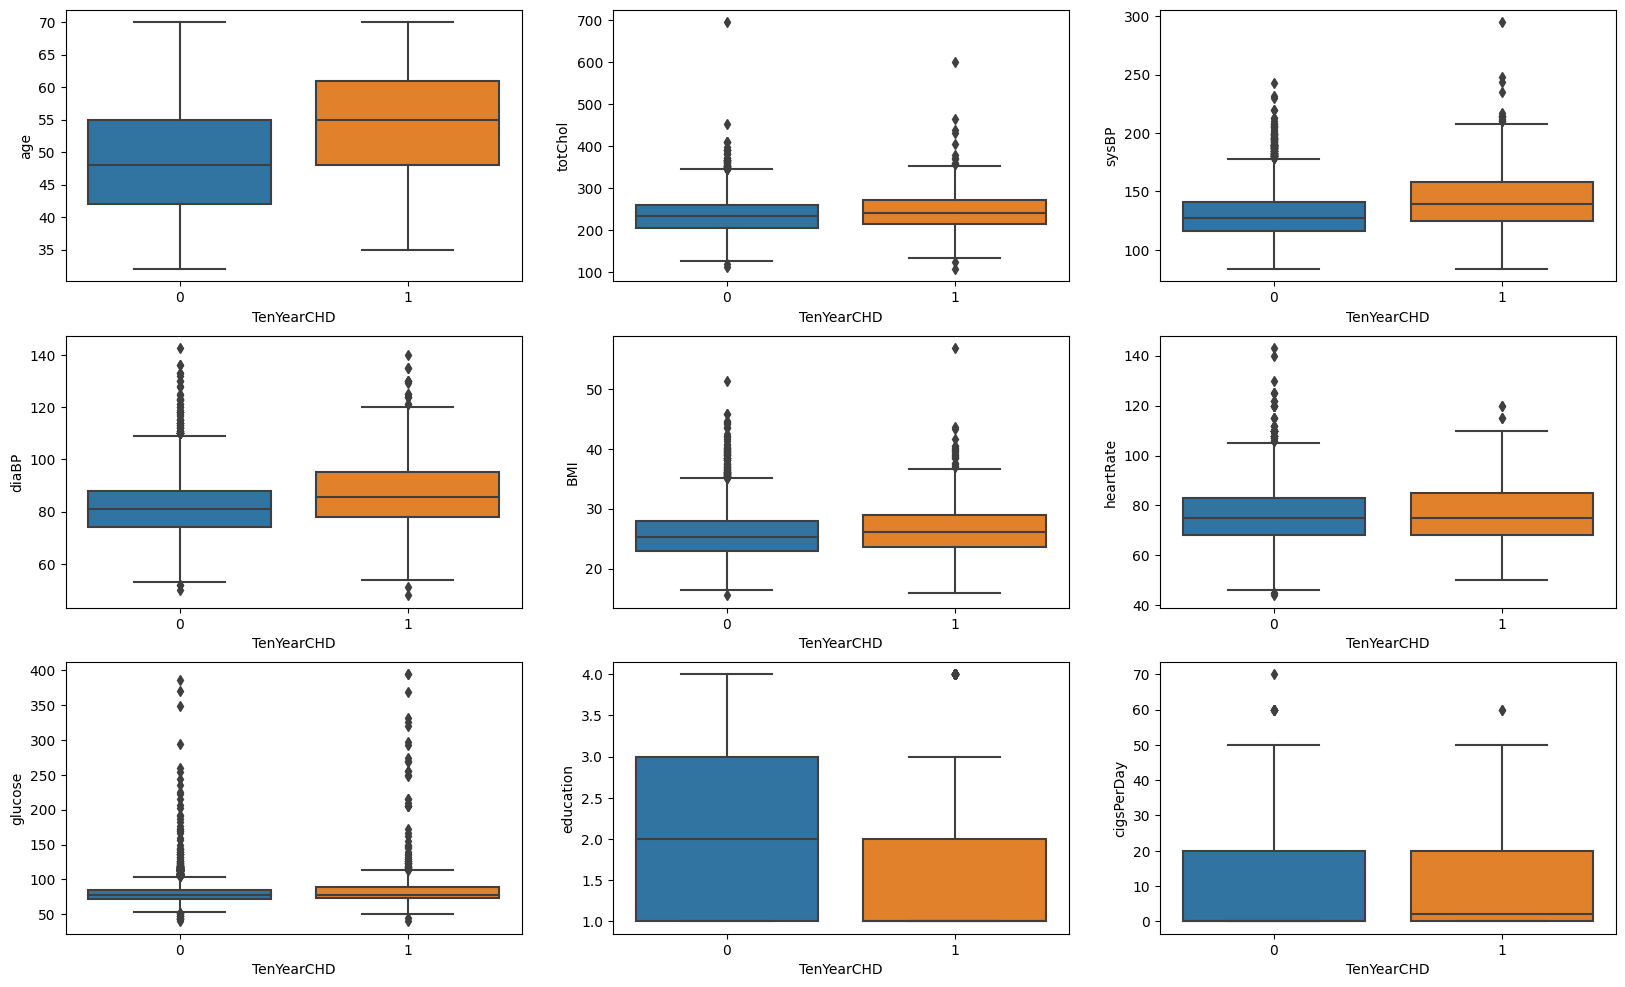

In [13]:
#Visualizing numerical variables

plt.figure(figsize=(20, 12))
plt.subplot(3,3,1)
sns.boxplot(x = 'TenYearCHD', y = 'age', data = data)
plt.subplot(3,3,2)
sns.boxplot(x = 'TenYearCHD', y = 'totChol', data = data)
plt.subplot(3,3,3)
sns.boxplot(x = 'TenYearCHD', y = 'sysBP', data = data)
plt.subplot(3,3,4)
sns.boxplot(x = 'TenYearCHD', y = 'diaBP', data = data)
plt.subplot(3,3,5)
sns.boxplot(x = 'TenYearCHD', y = 'BMI', data = data)
plt.subplot(3,3,6)
sns.boxplot(x = 'TenYearCHD', y = 'heartRate', data = data)
plt.subplot(3,3,7)
sns.boxplot(x = 'TenYearCHD', y = 'glucose', data = data)
plt.subplot(3,3,8)
sns.boxplot(x = 'TenYearCHD', y = 'education', data = data)
plt.subplot(3,3,9)
sns.boxplot(x = 'TenYearCHD', y = 'cigsPerDay', data = data)
plt.show()

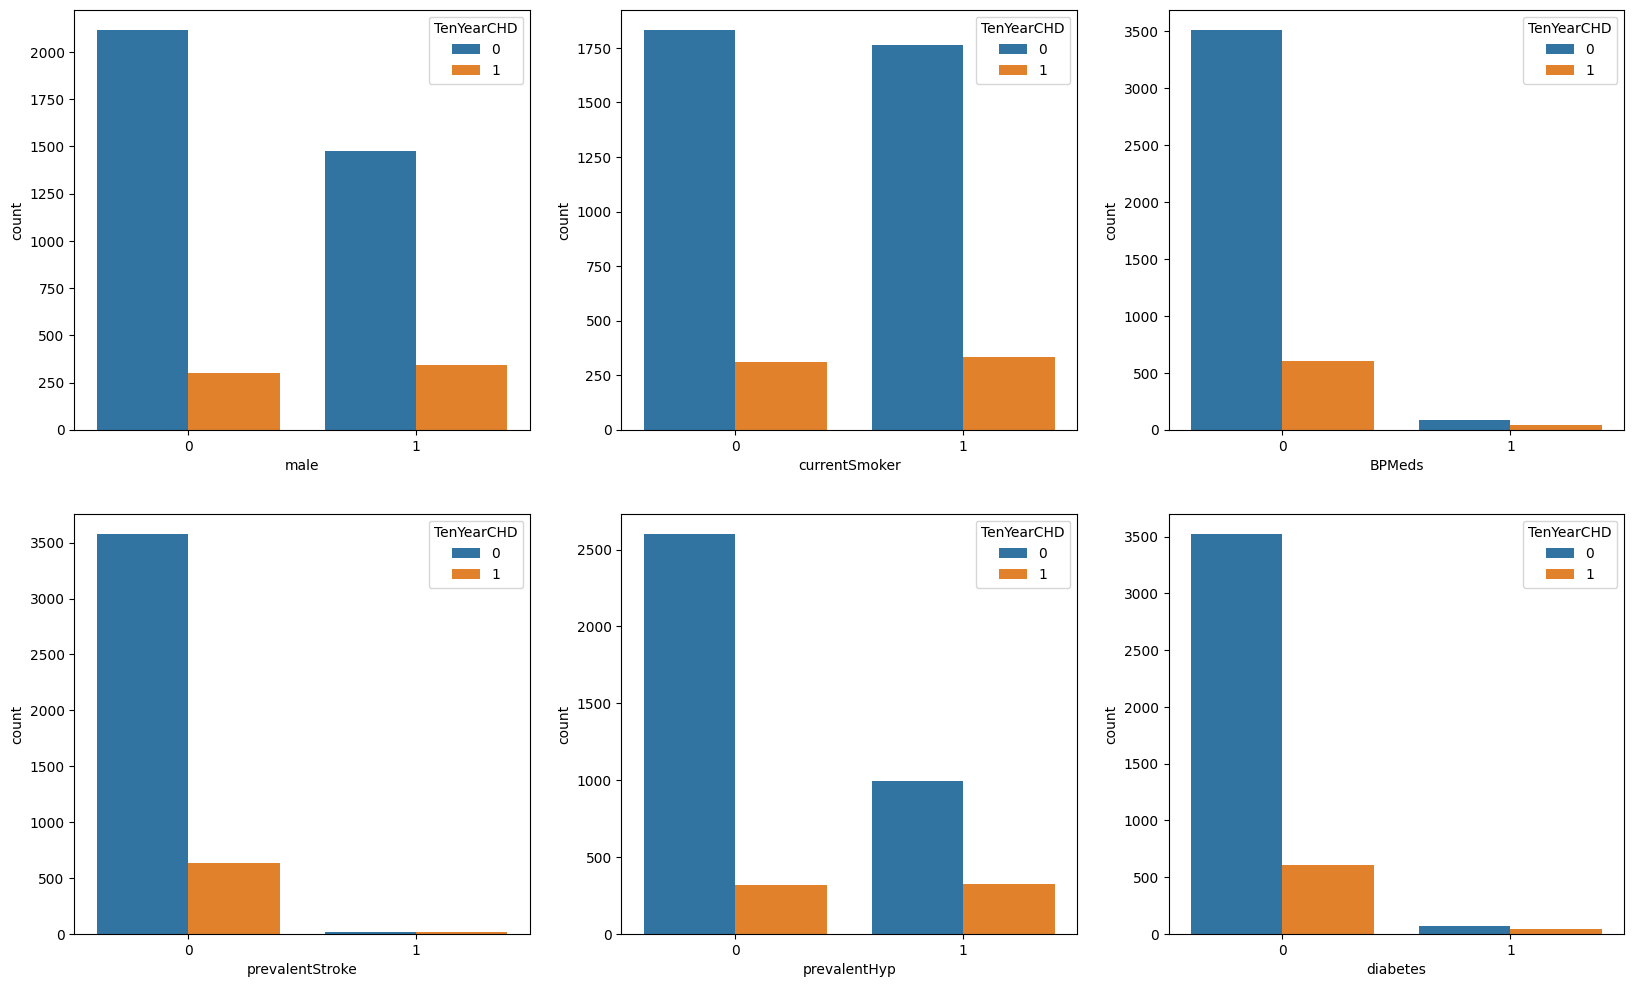

In [14]:

plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.countplot(x ='male', hue = 'TenYearCHD', data = data)
plt.subplot(2,3,2)
sns.countplot(x ='currentSmoker', hue = 'TenYearCHD', data = data)
plt.subplot(2,3,3)
sns.countplot(x ='BPMeds', hue = 'TenYearCHD', data = data)
plt.subplot(2,3,4)
sns.countplot(x ='prevalentStroke', hue = 'TenYearCHD', data = data)
plt.subplot(2,3,5)
sns.countplot(x ='prevalentHyp', hue = 'TenYearCHD', data = data)
plt.subplot(2,3,6)
sns.countplot(x ='diabetes', hue = 'TenYearCHD', data = data)
plt.show()

In [15]:
len(data.columns)

16

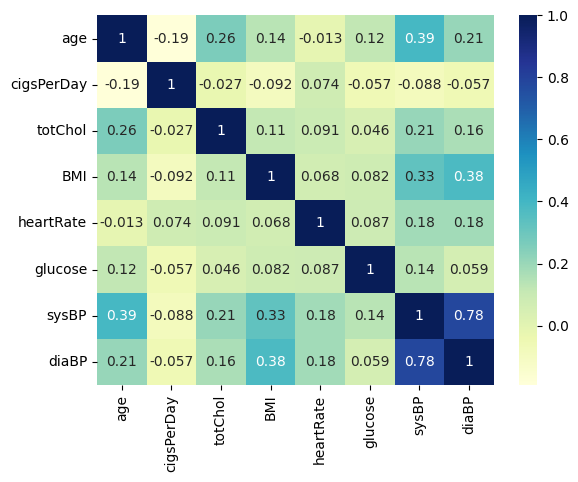

In [16]:
#Correlation of output with numerical variables
numerical_columns = ['age', 'cigsPerDay', 'totChol', 'BMI','heartRate', 'glucose', 'sysBP','diaBP']

# plotting correlation heatmap
dataplot = sns.heatmap(data[numerical_columns].corr(), cmap="YlGnBu", annot=True)
  

In [17]:
# Highly correlated features

#sysBP: Systolic Blood Pressure - The pressure exerted when the heartbeats
#diaBP: Diastolic Blood Pressure - The pressure exerted on the walls of the arteries when the heart muscles relax 
#in between two beats

#Both systolic and diastolic blood pressure are important indicators of cardiovascular health, 
#and both can be associated with an increased risk of heart disease. 

# However, the relationship between blood pressure and heart disease is complex, 
#and both systolic and diastolic pressure readings are often considered together 
# to provide a more comprehensive assessment.

# Step 4
# Convert data to features
# here we already have all the data points in numerical format so no need additonal steps

In [18]:
data.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2,0,0.0,0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1,0,0.0,0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2,1,20.0,0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1,0,0.0,0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,1,30.0,0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [1]:
# we did not scale the values of numerical variables

# Step 5
# Train and evaluate the Model


In [19]:
def train_test_split_and_scale(data):
    y = data["TenYearCHD"]
    x = data.drop('TenYearCHD',axis=1)
    features = list(x.columns)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train) # scaling is done only on features
    x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test,features



    

In [20]:
x_train, x_test, y_train, y_test,features = train_test_split_and_scale(data)

In [21]:
Counter(y_train)

Counter({0: 2884, 1: 506})

In [22]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test,class_weight=None):
    lr = LogisticRegression(class_weight=class_weight)
    model = lr.fit(x_train, y_train) # model training
    lr_predict = lr.predict(x_test) # create predicted o/p 0/1
    lr_conf_matrix = confusion_matrix(y_test, lr_predict)
    lr_acc_score = accuracy_score(y_test, lr_predict)
    print("confussion matrix")
    print(lr_conf_matrix)
    print("\n")
    print("Accuracy of Logistic Regression:",lr_acc_score*100,'\n')
    print(classification_report(y_test,lr_predict))
    return model

In [23]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)
print("odds ratio", np.exp(model.coef_))

confussion matrix
[[710   0]
 [131   7]]


Accuracy of Logistic Regression: 84.55188679245283 

              precision    recall  f1-score   support

           0       0.84      1.00      0.92       710
           1       1.00      0.05      0.10       138

    accuracy                           0.85       848
   macro avg       0.92      0.53      0.51       848
weighted avg       0.87      0.85      0.78       848

odds ratio [[1.53159405 9.66011099 0.98226782 1.08687976 3.83528465 1.13955873
  2.32728811 1.51483848 1.67169999 2.24826392 5.0457246  0.74448347
  1.26862686 0.91114602 3.44963263]]


In [24]:
Counter(y_train)

Counter({0: 2884, 1: 506})

In [26]:
Counter(y_test)

Counter({0: 710, 1: 138})

# Step 6 - Improve the model

In [27]:
# define class weights
weight = {0:1, 1:4}
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,class_weight=weight)


confussion matrix
[[567 143]
 [ 61  77]]


Accuracy of Logistic Regression: 75.94339622641509 

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       710
           1       0.35      0.56      0.43       138

    accuracy                           0.76       848
   macro avg       0.63      0.68      0.64       848
weighted avg       0.81      0.76      0.78       848



In [28]:
results = pd.DataFrame(model.predict_proba(x_test))
results.columns = ['class_0_proba','class_1_proba']
results['predicted_class'] = model.predict(x_test)
results.head(10)

,class_0_proba,class_1_proba,predicted_class
0,0.718753,0.281247,0
1,0.528665,0.471335,0
2,0.266848,0.733152,1
3,0.718015,0.281985,0
4,0.648062,0.351938,0
5,0.768564,0.231436,0
6,0.330157,0.669843,1
7,0.824245,0.175755,0
8,0.885592,0.114408,0
9,0.623816,0.376184,0


In [29]:
#save and reuse the model

In [30]:
import joblib  # 'pip install joblib' if you get "Package Not found Error"
joblib.dump(model , 'model_classifier.pkl')

['model_classifier.pkl']

In [31]:
model_read = joblib.load('model_classifier.pkl')
model_read.predict(x_test)

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,

# Step 7 - Model interpretation

In [ ]:
# Feature importance
# Odds ratio well higher than 1: Increase in fetaure value increases probability of event(heart risk) hapenning

# Odds ratio well below 1: Increase in fetaure value decreases probability of event(heart risk) hapenning

# A feature with an odds ratio near zero typically suggests that the associated predictor has 
#a strong negative impact on the odds of the event occurring.

# Odds ratio near 1 indicates that feature may not be a strong predictor

In [33]:
odds_ratio = np.exp(model.coef_)[0]

for z in range(len(features)):
     print("Odds ratio for feature {} is {}".format(features[z], odds_ratio[z]))

Odds ratio for feature male is 1.5150047997755243
Odds ratio for feature age is 11.36580088349646
Odds ratio for feature education is 0.9967753123416369
Odds ratio for feature currentSmoker is 1.1109622412041982
Odds ratio for feature cigsPerDay is 4.225306861230662
Odds ratio for feature BPMeds is 1.1696935859570063
Odds ratio for feature prevalentStroke is 2.3399319630210234
Odds ratio for feature prevalentHyp is 1.4745537327635665
Odds ratio for feature diabetes is 1.7817836036998824
Odds ratio for feature totChol is 2.3326790285344994
Odds ratio for feature sysBP is 5.592734622154051
Odds ratio for feature diaBP is 0.6927504941921094
Odds ratio for feature BMI is 1.4758968369625172
Odds ratio for feature heartRate is 0.8941219550889168
Odds ratio for feature glucose is 2.7463690254516213
